In [3]:
# import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
print("Libraries Imported Successfully")

Libraries Imported Successfully


In [4]:
#step: 2 Load Dataset
df=pd.read_csv(r"C:\Users\shai\Desktop\ml_projects\GIT\DEEP_LEARNING\DATASETS\household_power_consumption.csv")
print("\nDataset Loaded Successfully")


Dataset Loaded Successfully


In [5]:
#step: 3 Data Exploration

print("\nShape of Dataset")
print(df.shape)

print("\nFirst 5 Rows")
print(df.head())

print("\nDataset Information")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())


Shape of Dataset
(1048575, 9)

First 5 Rows
         Date      Time Global_active_power Global_reactive_power Voltage  \
0  16/12/2006  17:24:00               4.216                 0.418  234.84   
1  16/12/2006  17:25:00                5.36                 0.436  233.63   
2  16/12/2006  17:26:00               5.374                 0.498  233.29   
3  16/12/2006  17:27:00               5.388                 0.502  233.74   
4  16/12/2006  17:28:00               3.666                 0.528  235.68   

  Global_intensity Sub_metering_1 Sub_metering_2  Sub_metering_3  
0             18.4              0              1            17.0  
1               23              0              1            16.0  
2               23              0              2            17.0  
3               23              0              1            17.0  
4             15.8              0              1            17.0  

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 

In [6]:
#step: 4 Data Preprocessing
df.replace('?',np.nan, inplace=True)

In [7]:
#convert numerical columns

numeric_columns = [
    'Global_active_power',
    'Global_reactive_power',
    'Voltage',
    'Global_intensity',
    'Sub_metering_1',
    'Sub_metering_2',
    'Sub_metering_3'
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col],errors='coerce')

#Fill missing values

df.fillna(method='ffill',inplace=True)


C:\Users\shai\AppData\Local\Temp\ipykernel_10136\694112220.py:18: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill',inplace=True)


In [8]:
#create Datetime column

df['Datetime'] = pd.to_datetime(
    df['Date']+' '+df['Time'],
    dayfirst=True
)

In [9]:
#sort dataset

df = df.sort_values("Datetime")


In [10]:
# set datetime as index

df.set_index("Datetime", inplace=True)

print("\nData After Cleaning")
print(df.head())


Data After Cleaning
                           Date      Time  Global_active_power  \
Datetime                                                         
2006-12-16 17:24:00  16/12/2006  17:24:00                4.216   
2006-12-16 17:25:00  16/12/2006  17:25:00                5.360   
2006-12-16 17:26:00  16/12/2006  17:26:00                5.374   
2006-12-16 17:27:00  16/12/2006  17:27:00                5.388   
2006-12-16 17:28:00  16/12/2006  17:28:00                3.666   

                     Global_reactive_power  Voltage  Global_intensity  \
Datetime                                                                
2006-12-16 17:24:00                  0.418   234.84              18.4   
2006-12-16 17:25:00                  0.436   233.63              23.0   
2006-12-16 17:26:00                  0.498   233.29              23.0   
2006-12-16 17:27:00                  0.502   233.74              23.0   
2006-12-16 17:28:00                  0.528   235.68              15.8   

    

In [11]:
# step: 5 Feature Selection 

features = [
    'Global_active_power',
    'Global_reactive_power',
    'Voltage',
    'Global_intensity',
    'Sub_metering_1',
    'Sub_metering_2',
    'Sub_metering_3'
]

data = df[features]

print("\nSelected Features")
print(data.head())


Selected Features
                     Global_active_power  Global_reactive_power  Voltage  \
Datetime                                                                   
2006-12-16 17:24:00                4.216                  0.418   234.84   
2006-12-16 17:25:00                5.360                  0.436   233.63   
2006-12-16 17:26:00                5.374                  0.498   233.29   
2006-12-16 17:27:00                5.388                  0.502   233.74   
2006-12-16 17:28:00                3.666                  0.528   235.68   

                     Global_intensity  Sub_metering_1  Sub_metering_2  \
Datetime                                                                
2006-12-16 17:24:00              18.4             0.0             1.0   
2006-12-16 17:25:00              23.0             0.0             1.0   
2006-12-16 17:26:00              23.0             0.0             2.0   
2006-12-16 17:27:00              23.0             0.0             1.0   
2006-12-16

In [12]:
#step: 6 Feature Scaling

scaler= MinMaxScaler()

scaled_data = scaler.fit_transform(data)
print("\nScaled Data Shape")
print(scaled_data.shape)


Scaled Data Shape
(1048575, 7)


In [13]:
#step: 7 Create Time-Series Sequences

# We will use the past 30 timesteps to predict
# the next Global Active Power value.

sequence_length = 30
X=[]
y=[]
for i in range(sequence_length,len(scaled_data)):
    #Previous 30 rows
    X.append(scaled_data[i-sequence_length:i])
    #predict Global_active_power (column 0)
    y.append(scaled_data[i,0])


In [14]:
#convert t Numpy arrays

X=np.array(X)
y=np.array(y)

print("X shape :",X.shape)
print("y shape :",y.shape)

# example:
# X -> (samples, 30, 7)
# y -> (samples,)

X shape : (1048545, 30, 7)
y shape : (1048545,)


In [15]:
#step: 8 Train-test Split

# use 80% data for training

train_size= int(len(X) * 0.80)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print("\nTraining Samples :", len(X_train))
print("Testing Samples :", len(X_test))

print("\nX_train shape :", X_train.shape)
print("x_test Shape :",X_test.shape)

print("\ny_train shape :", y_train.shape)
print("y_test Shape :",y_test.shape)


Training Samples : 838836
Testing Samples : 209709

X_train shape : (838836, 30, 7)
x_test Shape : (209709, 30, 7)

y_train shape : (838836,)
y_test Shape : (209709,)


In [16]:
# step: 9 Check one Training Sample

print("\nOne Sequence Shape:")
print(X_train[0].shape)

print("\nTarget VAlue:")
print(y_train[0])

# X_train contains:
# 30 timesteps × 7 features

# y_train contains:
# Next Global Active Power value


One Sequence Shape:
(30, 7)

Target VAlue:
0.24957523126297906


In [17]:
# STEP 10: Build the SimpleRNN Model

model = Sequential()

model.add(
    SimpleRNN(
        units=64,
        activation='tanh',
        return_sequences=True,
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

c:\Users\shai\Desktop\ml_projects\venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [18]:
# Dropout Layer
model.add(Dropout(0.2))

In [19]:
# Second SimpleRNN Layer
model.add(
    SimpleRNN(
        units=32,
        activation='tanh'
    )
)

In [20]:
# Another Dropout Layer
model.add(Dropout(0.2))

In [21]:
# Output Layer
model.add(Dense(1))

In [22]:
# Display Model Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 30, 64)         │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,745 (30.25 KB)

 Trainable params: 7,745 (30.25 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
# STEP 11: Compile the Model

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

print("\nModel Compiled Successfully")


Model Compiled Successfully


In [24]:
# STEP 12: Early Stopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [25]:
# STEP 13: Train the Model
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/20
13107/13107 ━━━━━━━━━━━━━━━━━━━━ 108s 8ms/step - loss: 0.0024 - mae: 0.0232 - val_loss: 5.4505e-04 - val_mae: 0.0123
Epoch 2/20
13107/13107 ━━━━━━━━━━━━━━━━━━━━ 83s 6ms/step - loss: 8.7544e-04 - mae: 0.0151 - val_loss: 5.4042e-04 - val_mae: 0.0135
Epoch 3/20
13107/13107 ━━━━━━━━━━━━━━━━━━━━ 143s 6ms/step - loss: 8.6777e-04 - mae: 0.0150 - val_loss: 4.9063e-04 - val_mae: 0.0099
Epoch 4/20
13107/13107 ━━━━━━━━━━━━━━━━━━━━ 83s 6ms/step - loss: 8.6589e-04 - mae: 0.0149 - val_loss: 5.0442e-04 - val_mae: 0.0101
Epoch 5/20
13107/13107 ━━━━━━━━━━━━━━━━━━━━ 83s 6ms/step - loss: 8.6391e-04 - mae: 0.0149 - val_loss: 4.8507e-04 - val_mae: 0.0089
Epoch 6/20
13107/13107 ━━━━━━━━━━━━━━━━━━━━ 83s 6ms/step - loss: 8.6300e-04 - mae: 0.0149 - val_loss: 5.2889e-04 - val_mae: 0.0127
Epoch 7/20
13107/13107 ━━━━━━━━━━━━━━━━━━━━ 83s 6ms/step - loss: 8.5918e-04 - mae: 0.0148 - val_loss: 4.8841e-04 - val_mae: 0.0090
Epoch 8/20
13107/13107 ━━━━━━━━━━━━━━━━━━━━ 83s 6ms/step - loss: 8.6433e-04 - mae: 0.

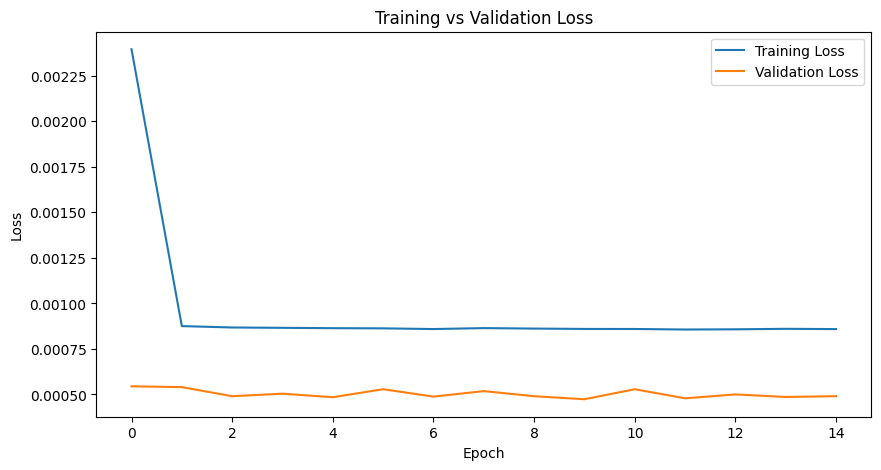

In [26]:
# STEP 14: Plot Training & Validation Loss

plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [27]:
# STEP 15: Predict on Test Data

y_pred = model.predict(X_test)

print("Prediction Completed!")

6554/6554 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step
Prediction Completed!


In [28]:
# STEP 16: Convert Predictions Back to Original Scale
# Since only Global_active_power (column 0) is predicted,
# create dummy arrays with 7 features for inverse scaling.

dummy_pred = np.zeros((len(y_pred), len(features)))
dummy_test = np.zeros((len(y_test), len(features)))

dummy_pred[:, 0] = y_pred.flatten()
dummy_test[:, 0] = y_test


In [29]:
# Convert back to original values

y_pred_actual = scaler.inverse_transform(dummy_pred)[:, 0]
y_test_actual = scaler.inverse_transform(dummy_test)[:, 0]

In [30]:
# STEP 17: Calculate RMSE & MAE

rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
mae = mean_absolute_error(y_test_actual, y_pred_actual)

print("\nModel Evaluation")
print("----------------------------")
print("RMSE :", rmse)
print("MAE  :", mae)


Model Evaluation
----------------------------
RMSE : 0.23066454392512858
MAE  : 0.08640052825002015


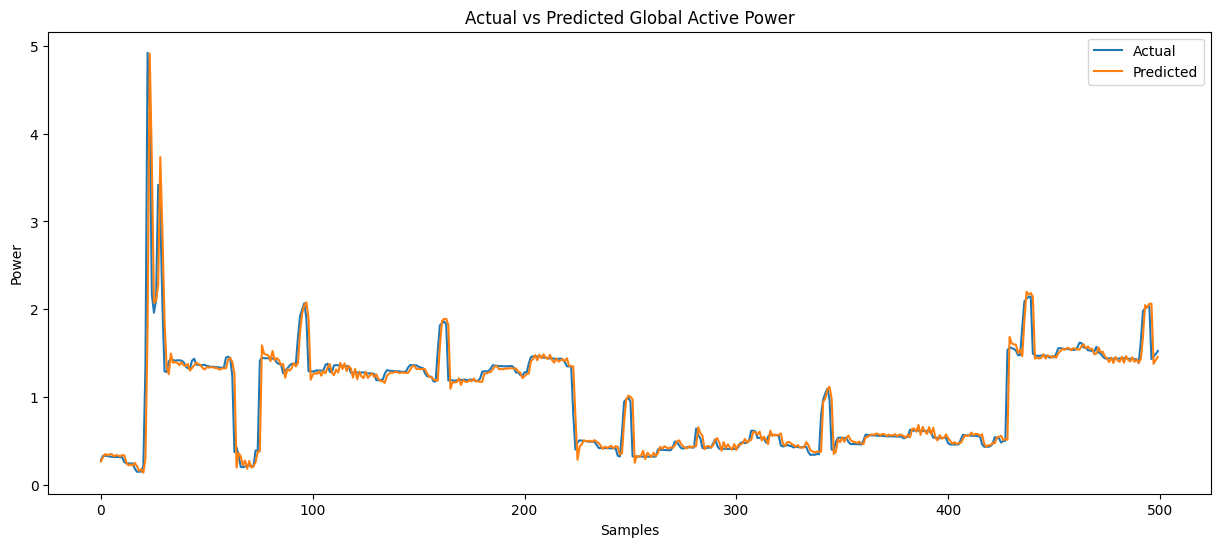

In [31]:
# STEP 18: Plot Actual vs Predicted

plt.figure(figsize=(15,6))

plt.plot(y_test_actual[:500], label="Actual")
plt.plot(y_pred_actual[:500], label="Predicted")

plt.title("Actual vs Predicted Global Active Power")
plt.xlabel("Samples")
plt.ylabel("Power")
plt.legend()

plt.show()

In [32]:
# STEP 19: Save the Model

model.save("SimpleRNN_household_power.h5")

print("\nModel Saved Successfully!")


Model Saved Successfully!


In [33]:
# STEP 20: Reload the Saved Model

loaded_model = load_model(
    r"C:\Users\shai\Desktop\ml_projects\GIT\DEEP_LEARNING\RNN\SimpleRNN_household_power.h5",
    custom_objects={'mse': tf.keras.metrics.MeanSquaredError(), 'mae': tf.keras.metrics.MeanAbsoluteError()}
)

print("Saved Model Loaded Successfully!")

Saved Model Loaded Successfully!


In [34]:
# STEP 21: Predict Next Value

# Take the last sequence from the dataset

last_sequence = scaled_data[-sequence_length:]

# Reshape for RNN input

last_sequence = last_sequence.reshape(
    1,
    sequence_length,
    len(features)
)

# Predict next value

next_prediction = loaded_model.predict(last_sequence)

# Convert prediction back to original scale

dummy_next = np.zeros((1, len(features)))
dummy_next[:, 0] = next_prediction.flatten()

next_value = scaler.inverse_transform(dummy_next)[0, 0]

print("\n=====================================")
print("Predicted Next Global Active Power")
print("=====================================")
print(next_value)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step

Predicted Next Global Active Power
0.4178419314473867


In [35]:
# STEP 22: Display Some Predictions

comparison = pd.DataFrame({
    "Actual": y_test_actual[:20],
    "Predicted": y_pred_actual[:20]
})

print("\nFirst 20 Predictions")
print(comparison)


First 20 Predictions
    Actual  Predicted
0    0.288   0.268765
1    0.334   0.320413
2    0.332   0.353788
3    0.332   0.337240
4    0.326   0.349400
5    0.322   0.353039
6    0.320   0.328761
7    0.320   0.339383
8    0.320   0.337308
9    0.318   0.327338
10   0.318   0.341027
11   0.262   0.338814
12   0.248   0.252627
13   0.248   0.225293
14   0.246   0.235677
15   0.246   0.221427
16   0.186   0.253411
17   0.152   0.213603
18   0.152   0.163207
19   0.154   0.179739
